In [1]:
from pyclipse.layer import LobeLayer
import matplotlib.pyplot as plt
import numpy as np
import pyvista as pv

In [2]:
dhmax = 25
layer1 = LobeLayer(nx=300, ny=300, nz=250+2*dhmax, x_len=15000, y_len=15000, z_len=500, top_depth=0, dip=20, poro_ave=0.17,
                   poro_std=0.03, perm_ave=np.log10(10), perm_std=0.5, kzkx=1, ntg=1)
layer1.create_geology(dhmin=15, dhmax=dhmax, rmin=100, rmax=150, asp=1.6, theta0=0, m=2, upthinning=False, bouma_factor=3/4)

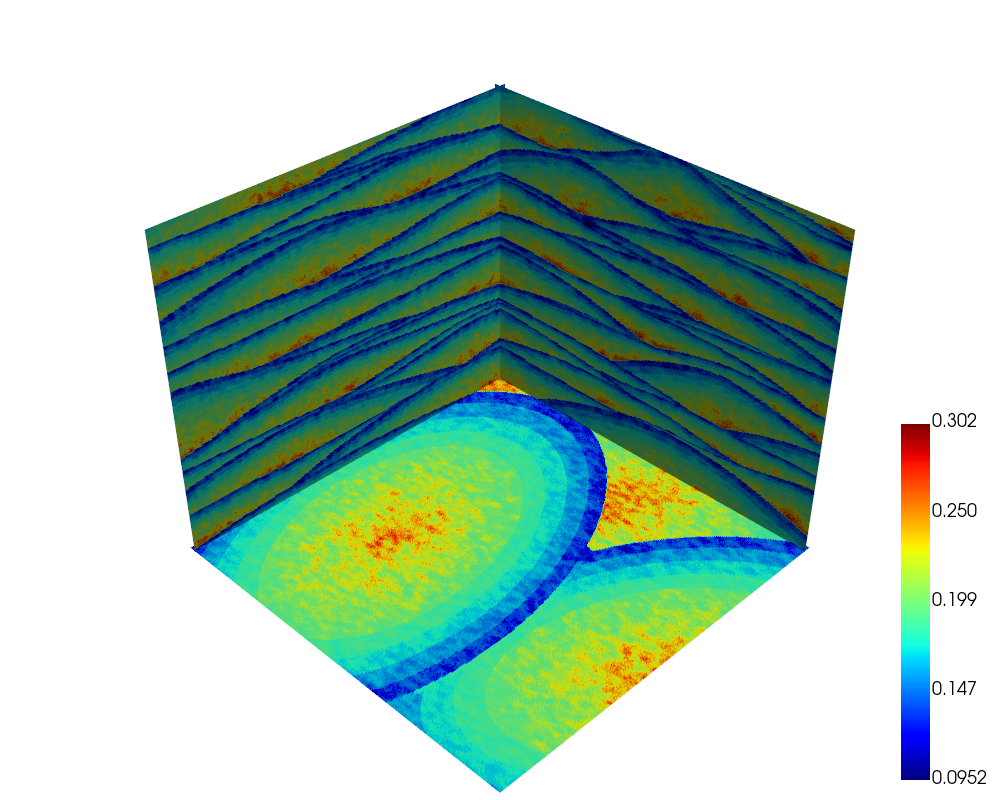

In [4]:
# grid = pv.wrap(final_grid)
grid = pv.wrap(layer1.poro_mat[:,:,:-2*dhmax])
# --- Modification ---
# Define the arguments for the scalar bar (color bar)
sargs = dict(
    vertical=True,  # Set the orientation to vertical
    title=''
)

slices = grid.slice_orthogonal(x=5, y=5, z=1)

p = pv.Plotter()
p.add_mesh(slices, cmap='jet',scalar_bar_args=sargs)
p.background_color = "white"
p.show(jupyter_backend='static', window_size=(1000,800))

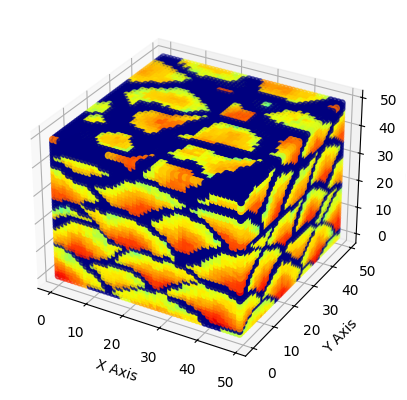

In [ ]:
fig = plt.figure()
ax = fig.add_subplot(111, projection='3d')

# Extract x, y, and z coordinates from the numpy array
x, y, z = np.indices(layer1.poro_mat[:,:,:-2*dhmax].shape)
vals = layer1.poro_mat[:,:,:-2*dhmax].flatten()

# Flatten the numpy array and use it as the values for the 3D plot
ax.scatter(x.flatten(), y.flatten(), z.flatten(), c=vals, cmap='jet')
ax.set_xlabel('X Axis')
ax.set_ylabel('Y Axis')
ax.set_zlabel('Z Axis')
plt.show()

In [3]:
from pathlib import Path
# 1. Define the directory and filename
output_dir = Path("C:/Users/er34726/Desktop/exxon_data")
file_name = "trial_bouma3.npy"


# 3. Combine them and save
file_path = output_dir / file_name
np.save(file_path, layer1.poro_mat[:,:,:-2*dhmax])
